<a href="https://colab.research.google.com/github/mahisoft-link/Capstone_project_on_python/blob/main/trader_performance_and_market_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Objective**: *objective is to explore the relationship between trader performance and market sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading strategies.*


import the library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load the data
sentiment = pd.read_csv("/content/fear_greed_index.csv")
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
sentiment.shape #tell coloum and row number

(2644, 4)

In [5]:
sentiment.columns #column name

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [6]:
sentiment.isnull().sum() #checking missing value

,0
timestamp,0
value,0
classification,0
date,0


In [7]:
sentiment.duplicated().sum() #cheking the duplicated value

np.int64(0)

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
sentiment['date'] = pd.to_datetime(sentiment['date'], format="%Y-%m-%d")

In [10]:
#load 2nd dataset
historical = pd.read_csv("/content/historical_data.csv")
historical.head()

/tmp/ipython-input-2149894203.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  historical = pd.read_csv("/content/historical_data.csv")


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
historical.isnull().sum()  #checking missing value

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [12]:
historical.shape

(37109, 16)

In [13]:
historical.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [14]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37109 entries, 0 to 37108
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           37109 non-null  object 
 1   Coin              37109 non-null  object 
 2   Execution Price   37109 non-null  float64
 3   Size Tokens       37109 non-null  float64
 4   Size USD          37109 non-null  float64
 5   Side              37109 non-null  object 
 6   Timestamp IST     37109 non-null  object 
 7   Start Position    37109 non-null  float64
 8   Direction         37109 non-null  object 
 9   Closed PnL        37109 non-null  float64
 10  Transaction Hash  37109 non-null  object 
 11  Order ID          37108 non-null  float64
 12  Crossed           37108 non-null  object 
 13  Fee               37108 non-null  float64
 14  Trade ID          37108 non-null  float64
 15  Timestamp         37108 non-null  float64
dtypes: float64(9), object(7)
memory usage: 4

In [15]:
historical['date'] = pd.to_datetime(historical['Timestamp IST'], format= "%d-%m-%Y %H:%M")
historical['date'] = historical['date'].dt.date
historical['date'] = pd.to_datetime(historical['date'], format = "%d-%m-%Y")

In [16]:
historical['date'].dtypes

dtype('<M8[ns]')

In [17]:
data = pd.merge(sentiment,historical, how ='inner',on='date' )

In [18]:
data.head()

,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,1705642200,51,Neutral,2024-01-19,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,ETH,2466.4,0.1000,246.64,BUY,19-01-2024 06:47,0.0000,Open Long,0.000,0xfe658713a620cd6cfc8204073770c0018600849ff0be...,7.478562e+09,True,0.059193,4.990000e+14,1.710000e+12
1,1705642200,51,Neutral,2024-01-19,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,ETH,2466.0,0.1000,246.60,SELL,19-01-2024 06:47,0.1000,Close Long,-0.040,0x607bdd7ad9a172d68d9504073770d20151009e82be59...,7.478572e+09,True,0.059184,1.110000e+15,1.710000e+12
2,1705642200,51,Neutral,2024-01-19,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,ETH,2462.4,0.0100,24.62,BUY,19-01-2024 07:45,0.0000,Open Long,0.000,0x584c9dda3b0b50614198040737977d01110044cf7661...,7.482293e+09,True,0.005909,6.980000e+14,1.710000e+12
3,1705642200,51,Neutral,2024-01-19,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,ETH,2459.0,0.0122,30.00,SELL,19-01-2024 07:57,0.0100,Long > Short,-0.034,0x1dde0bab3b9bcb7d81cc0407379f6e02016f002ad4df...,7.482894e+09,True,0.007199,7.010000e+13,1.710000e+12
4,1705642200,51,Neutral,2024-01-19,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,ETH,2459.0,0.0062,15.25,SELL,19-01-2024 07:57,-0.0022,Open Short,0.000,0x1dde0bab3b9bcb7d81cc0407379f6e02016f002ad4df...,7.482894e+09,True,0.003658,8.260000e+14,1.710000e+12


In [19]:
data.describe(include='all')


,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,3.710300e+04,37103.000000,37103,37103,37103,37103,37103.000000,3.710300e+04,3.710300e+04,37103,37103,3.710300e+04,37103,37103.000000,37103,3.710200e+04,37102,37102.000000,3.710200e+04,3.710200e+04
unique,NaN,NaN,5,NaN,8,132,NaN,NaN,NaN,2,3526,NaN,10,NaN,16564,NaN,2,NaN,NaN,NaN
top,NaN,NaN,Fear,NaN,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,NaN,NaN,NaN,BUY,14-02-2025 00:31,NaN,Close Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,NaN,NaN,10909,NaN,12236,14875,NaN,NaN,NaN,18710,441,NaN,11124,NaN,689,NaN,22514,NaN,NaN,NaN
mean,1.736601e+09,55.154058,NaN,2025-01-11 07:38:12.073417216,NaN,NaN,36279.449486,1.474963e+04,1.766704e+04,NaN,NaN,2.477084e+03,NaN,107.863693,NaN,6.639277e+10,NaN,3.552149,5.641734e+14,1.736775e+12
min,1.705642e+09,10.000000,NaN,2024-01-19 00:00:00,NaN,NaN,0.000010,1.000000e-05,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,7.478562e+09,NaN,-1.175712,0.000000e+00,1.710000e+12
25%,1.734673e+09,43.000000,NaN,2024-12-20 00:00:00,NaN,NaN,6.493400,1.195000e-01,4.512800e+02,NaN,NaN,-6.042641e+01,NaN,0.000000,NaN,5.706810e+10,NaN,0.016774,2.820000e+14,1.730000e+12
50%,1.739511e+09,54.000000,NaN,2025-02-14 00:00:00,NaN,NaN,2661.500000,2.000000e+00,1.610260e+03,NaN,NaN,4.752390e+00,NaN,0.000000,NaN,7.208909e+10,NaN,0.217036,5.630000e+14,1.740000e+12
75%,1.744609e+09,72.000000,NaN,2025-04-14 00:00:00,NaN,NaN,85300.000000,1.460000e+02,9.999880e+03,NaN,NaN,5.427450e+02,NaN,19.935246,NaN,8.627714e+10,NaN,2.238330,8.480000e+14,1.740000e+12
max,1.746077e+09,94.000000,NaN,2025-05-01 00:00:00,NaN,NaN,108410.000000,1.150000e+07,3.921431e+06,NaN,NaN,1.150000e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12


In [20]:
for i in data.columns.to_list():
  print("No of unique value in",i,"is",data[i].nunique())

No of unique value in timestamp is 384
No of unique value in value is 71
No of unique value in classification is 5
No of unique value in date is 384
No of unique value in Account is 8
No of unique value in Coin is 132
No of unique value in Execution Price is 10848
No of unique value in Size Tokens is 19341
No of unique value in Size USD is 27627
No of unique value in Side is 2
No of unique value in Timestamp IST is 3526
No of unique value in Start Position is 35762
No of unique value in Direction is 10
No of unique value in Closed PnL is 16281
No of unique value in Transaction Hash is 16564
No of unique value in Order ID is 4093
No of unique value in Crossed is 2
No of unique value in Fee is 27903
No of unique value in Trade ID is 2061
No of unique value in Timestamp is 5


In [21]:
data.columns

Index(['timestamp', 'value', 'classification', 'date', 'Account', 'Coin',
       'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST',
       'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp'],
      dtype='object')

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37103 entries, 0 to 37102
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         37103 non-null  int64         
 1   value             37103 non-null  int64         
 2   classification    37103 non-null  object        
 3   date              37103 non-null  datetime64[ns]
 4   Account           37103 non-null  object        
 5   Coin              37103 non-null  object        
 6   Execution Price   37103 non-null  float64       
 7   Size Tokens       37103 non-null  float64       
 8   Size USD          37103 non-null  float64       
 9   Side              37103 non-null  object        
 10  Timestamp IST     37103 non-null  object        
 11  Start Position    37103 non-null  float64       
 12  Direction         37103 non-null  object        
 13  Closed PnL        37103 non-null  float64       
 14  Transaction Hash  3710

In [23]:
data['classification'].unique()

array(['Neutral', 'Greed', 'Extreme Greed', 'Fear', 'Extreme Fear'],
      dtype=object)

In [24]:
data['Closed PnL'] = round(data['Closed PnL'],2) #rounding the closed pnl value in 2 decimale

In [25]:
Trader_Net_profit_with_cost = data.groupby('classification')[['Closed PnL','Fee']].sum()  #classification according to netprofit
Trader_Net_profit_with_cost



,Closed PnL,Fee
classification,,
Extreme Fear,345821.62,4102.920115
Extreme Greed,445458.12,16719.982252
Fear,1652079.89,47277.227770
Greed,946198.25,40680.015862
Neutral,612508.96,23011.669631


In [26]:
Total_classification_value = data.groupby('classification')['value'].sum()  #Total value by clssification


In [27]:
Trade_exchange_cost_with_classification = data.groupby('classification')['Fee'].mean() #avg cost  classification
Trade_exchange_cost_with_classification

,Fee
classification,
Extreme Fear,2.728005
Extreme Greed,2.101292
Fear,4.333782
Greed,4.090911
Neutral,3.390052


In [28]:
net_outcome = data['Closed PnL'].sum() #Total outcome
print(f"net profit {net_outcome}")

net profit 4002066.84


In [29]:
avg_return = net_outcome.mean() #mean pnl per trade
avg_return

np.float64(4002066.84)

In [30]:
trader_side_count = data.groupby('classification')['Side'].value_counts()  #trader buy or sell token
trader_side_count

classification  Side
Extreme Fear    BUY      904
                SELL     600
Extreme Greed   SELL    4092
                BUY     3865
Fear            BUY     5708
                SELL    5201
Greed           SELL    5041
                BUY     4903
Neutral         SELL    3459
                BUY     3330
Name: count, dtype: int64

In [31]:
trade_avg_sizeeUSD = data.groupby("classification")[['Size USD']].mean() #trader performance average size USD value according to classification
trade_avg_sizeeUSD

,Size USD
classification,
Extreme Fear,11143.684122
Extreme Greed,8995.327006
Fear,25428.266009
Greed,18218.209690
Neutral,15997.242570


In [32]:
data['data_year'] = data.loc[:,'date'].dt.year #extract year form the date


In [33]:
trader_perfomance_year = data.groupby('data_year')['Closed PnL'].sum()  #trader perfomance(net profit) according to year
trader_perfomance_year

,Closed PnL
data_year,
2024,328041.42
2025,3674025.42


In [34]:
trader_performance_with_size = data.groupby('data_year')['Size USD'].mean()  #Trade total usd value according to year
trader_performance_with_size

,Size USD
data_year,
2024,7951.256271
2025,21136.017887


In [35]:
trader_performance_token_size = data.groupby('data_year')['Size Tokens'].mean()
trader_performance_token_size

,Size Tokens
data_year,
2024,28666.547683
2025,9780.646911


In [36]:
trader_performance_token_side = data.groupby('data_year')['Side'].value_counts()
trader_performance_token_side

data_year  Side
2024       SELL     5085
           BUY      4677
2025       BUY     14033
           SELL    13308
Name: count, dtype: int64

#**Relationship Measure** :**By visualization**


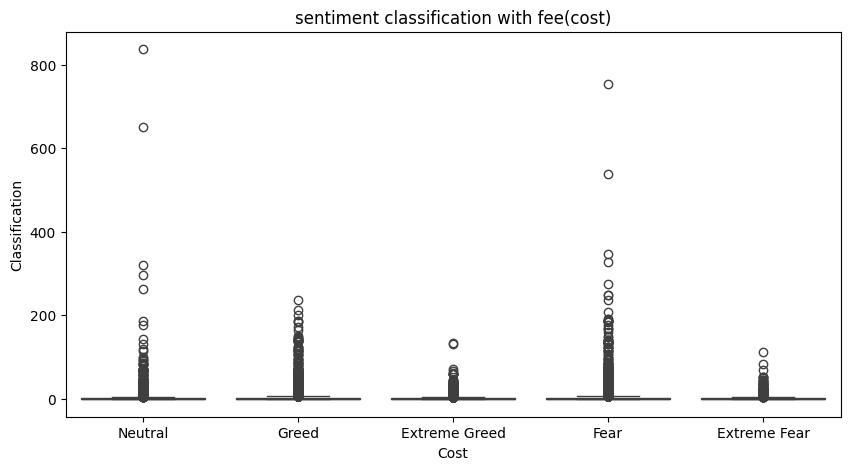

In [86]:
#sentiment classification with  fee(cost)
plt.figure(figsize=(10,5))
sns.boxplot(data,x='classification',y='Fee')
plt.xlabel("Cost")
plt.ylabel("Classification")
plt.title("sentiment classification with fee(cost)")
plt.show()

* As we can see that Extreme Fear has a minimum outliner.which mean extreme fear classified trader inncur minimum cost.
* In neutral clssification fees cost is highest.

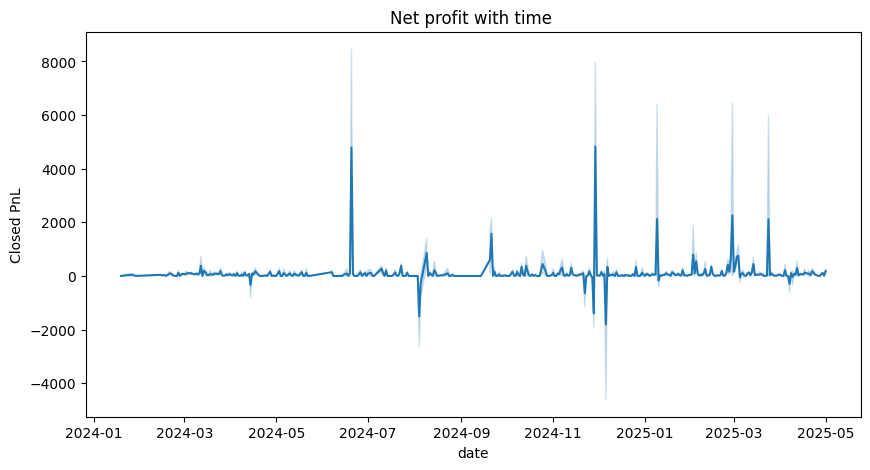

In [39]:
#netprofit with time
plt.figure(figsize=(10,5))
sns.lineplot(data = data,x='date',y='Closed PnL')
plt.title("Net profit with time ")
plt.show()

* in year **2024** august month trader get maximum net profit
* in between august 2024 to 2025 trader get also negetive profit
* After jan 2025 trader perfome well and got only positive profit


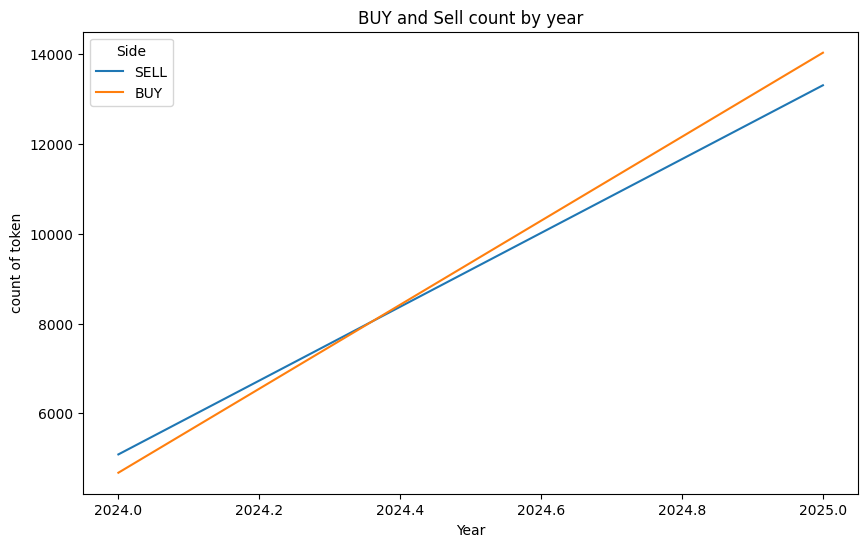

In [43]:
trader_performance_token_side = data.groupby('data_year')['Side'].value_counts()

# Convert the MultiIndex Series to a DataFrame for plotting
trader_performance_df = trader_performance_token_side.reset_index()
trader_performance_df.columns = ['data_year', 'Side', 'count'] # Rename columns for clarity

plt.figure(figsize=(10,6))
sns.lineplot(data = trader_performance_df, x= 'data_year',y = 'count',hue='Side')
plt.title("BUY and Sell count by year")
plt.xlabel("Year")
plt.ylabel("count of token")
plt.show()

* Before **april 2024** the sell is grater then buy
* after **april 2024** the sell gone low and and token buy increasing regularly


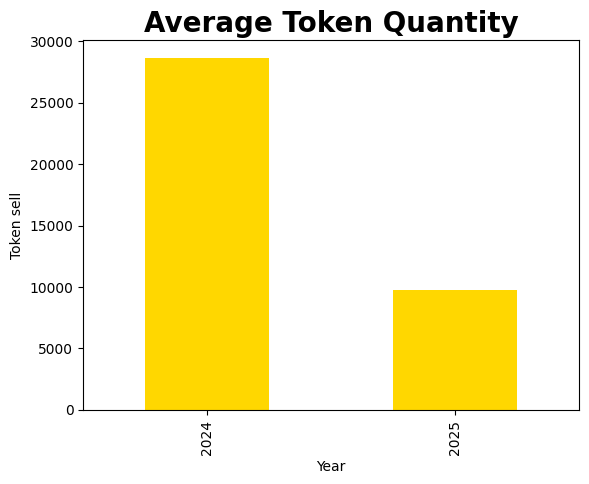

In [62]:
avg_trade_token_Quantity = data.groupby('data_year')['Size Tokens'].mean()
avg_trade_token_Quantity.plot(kind='bar',color= 'gold')
plt.title('Average Token Quantity',fontdict={'fontsize':20,'fontweight':'bold'})
plt.xlabel("Year")
plt.ylabel("Token sell")
plt.show()


* Because in 2024 sell less then the buy so quantity of token size is maximum


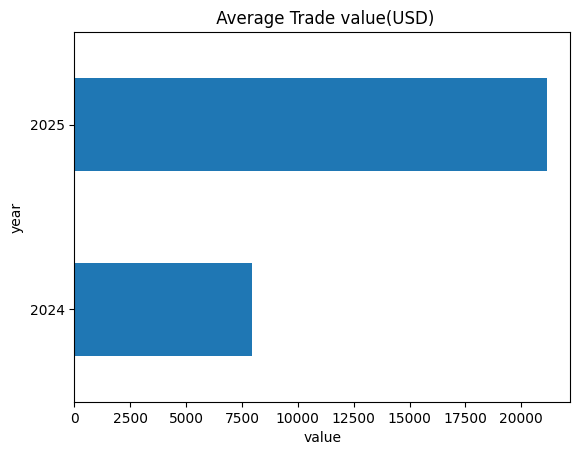

In [75]:
trader_avg_value_size_USD = data.groupby('data_year')['Size USD'].mean()  #Trade total usd value according to year
trader_avg_value_size_USD.plot(kind='barh')
plt.title(' Average Trade value(USD)')
plt.xlabel("value")
plt.ylabel("year")
plt.show()

* As we saw before that coin sell are increae in the 2025 result is that trade value increase. above diagram shwoing this relationship

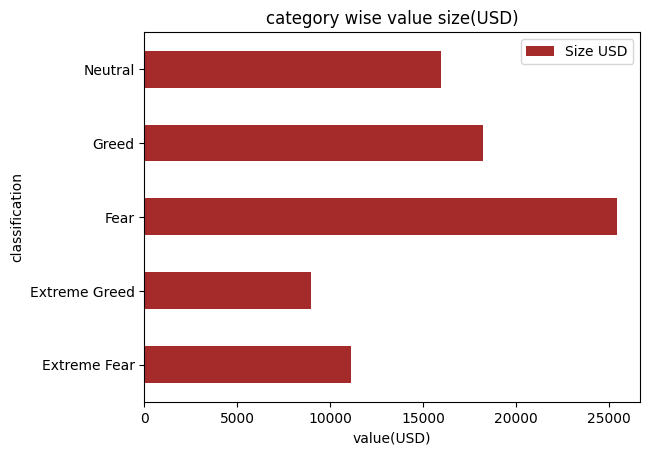

In [77]:
category_wise_avg_value_sizeUSD = data.groupby("classification")[['Size USD']].mean() #trader average size USD value according to classification
category_wise_avg_value_sizeUSD.plot(kind='barh',color='brown')
plt.title("category wise value size(USD)")
plt.xlabel("value(USD)")
plt.ylabel("classification")
plt.show()


* fear bar value is gratest in all : reson is that maximum people afraid to get loss so they choose minimum risk coin.
* Extreme Greed people quntity is minimum so value is also minimum.

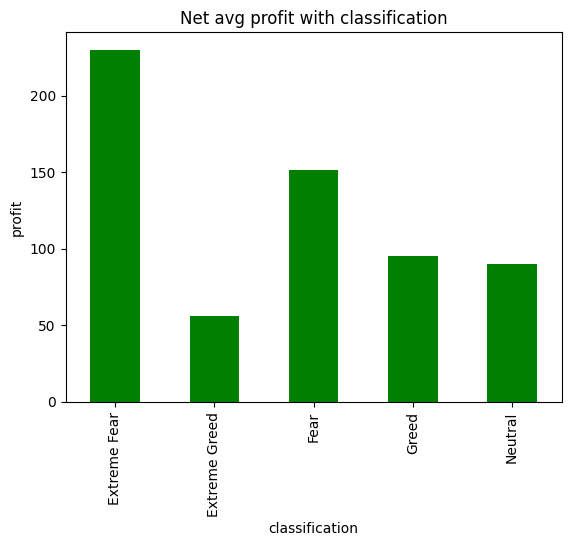

In [85]:
Trader_Net_profit = data.groupby('classification')['Closed PnL'].mean()   #classification according to netprofit
Trader_Net_profit.plot(kind = 'bar',color= 'green')
plt.title("Net avg profit with classification")
plt.xlabel('classification')
plt.ylabel('profit')
plt.show()


* By this graph we can see that **Extreme Fear** classification bar got the maximum profit


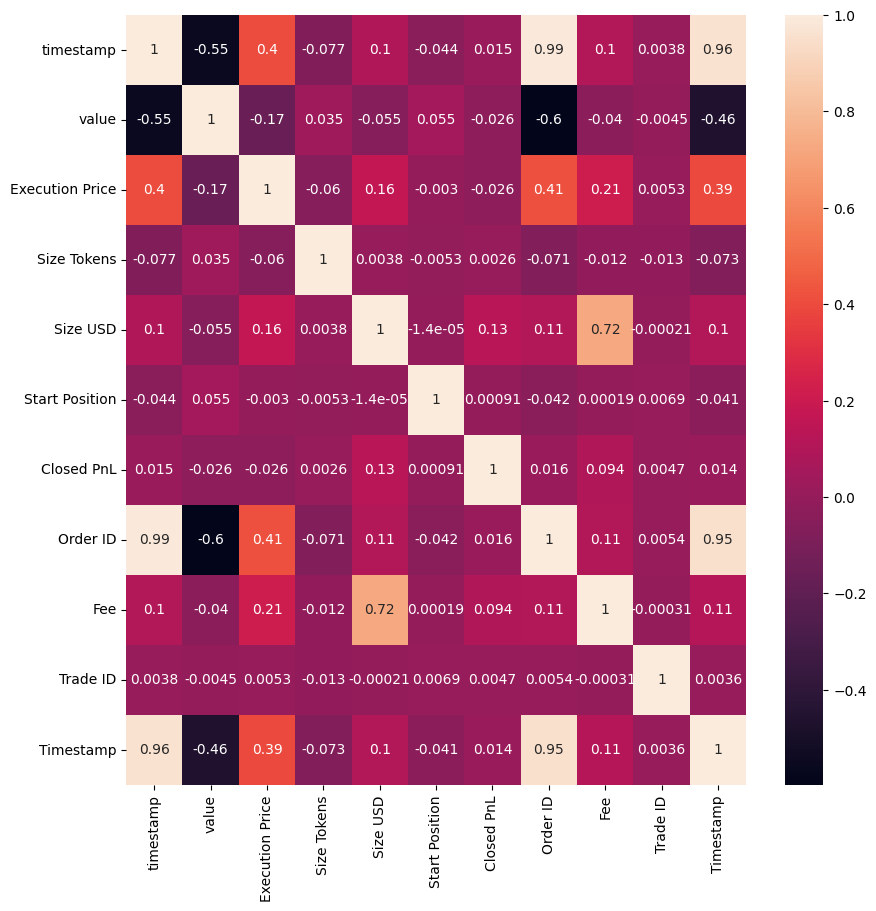

In [100]:
num_data = data.select_dtypes(include = ['int64','float64'])
plt.figure(figsize=(10,10))
sns.heatmap(num_data.corr(),annot=True)
plt.show()